In [77]:
from pytools4scarf import dataloader
import matplotlib.pyplot as plt
import numpy as np

In [78]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

In [79]:
from pathlib import Path
runs = [
    's20ns_mw5',  's20ns_mw7',
    's30ns_mw3',  's30ns_mw5',  's30ns_mw7',
    's40ns_mw1',  's40ns_mw3',  's40ns_mw5',  's40ns_mw7',
    's50ns_mw1',  's50ns_mw3',  's50ns_mw5',  's50ns_mw7',
    's60ns_mw1',  's60ns_mw3',  's60ns_mw5',  's60ns_mw7',
    's100ns_mw1', 's100ns_mw3', 's100ns_mw5', 's100ns_mw7',
    's200ns_mw1', 's200ns_mw3', 's200ns_mw5', 's200ns_mw7',
    's300ns_mw1', 's300ns_mw3', 's300ns_mw5', 's300ns_mw7','s300ns_mw15',
    's500ns_mw1', 's500ns_mw3', 's500ns_mw5', 's500ns_mw7','s500ns_mw15',
    's700ns_mw1', 's700ns_mw3', 's700ns_mw5', 's700ns_mw7','s700ns_mw15',
]

map_dir = Path(
    "/mnt/atlas02/users/leoli/self_metadata/vary_smoothing/maps_vcs"
)
def map_path(config):
    map_dir ="/mnt/atlas02/users/leoli/self_metadata/vary_smoothing/maps_vcs"
    return map_dir+"/map_calibration_"+config+".yaml"
data_cleaning_path = (
    "/mnt/atlas02/users/leoli/self_metadata/data_cleaning.yaml"
)
map_path('s100ns_mw5')

'/mnt/atlas02/users/leoli/self_metadata/vary_smoothing/maps_vcs/map_calibration_s100ns_mw5.yaml'

## select two configs to compare

In [ ]:
run_1 = "s40ns_mw7"
run_2 = "s60ns_mw7"

## ROI

### Event tier vetos

In [149]:
dfs_evt,lts_evt = {},{}
dfs_evt["r059"], lts_evt["r059"] = dataloader.load_lh5_run(
    ["ch002/evt"],
    "/mnt/atlas01/users/vogl/scarf/sp01/metadata/map.yaml",
    data_cleaning_path,
    "evt",
    "sp01",
    "p05",
    "r059",
    "phy",
    ["ch002"],
)

In [150]:
dfs_phy_evt = dfs_evt['r059']['ch002']

In [151]:
argon_veto = np.asarray(dfs_phy_evt.is_lar_vetoed)
muon_veto = np.asarray(dfs_phy_evt.is_muon)
alpha_veto = np.asarray(dfs_phy_evt.A_max_o_E_High_Side_Cut & (dfs_phy_evt.Iasy<0))

### readfiles

In [152]:
dfs_1, lts_1 = {}, {}
dfs_1["r059"], lts_1["r059"] = dataloader.load_lh5_run(
    ["ch002/hit"],
    map_path(run_1),
    data_cleaning_path,
    "hit",
    "sp01",
    "p05",
    "r059",
    "phy",
    ["ch002"],
)

In [153]:
dfs_2, lts_2 = {}, {}
dfs_2["r059"], lts_2["r059"] = dataloader.load_lh5_run(
    ["ch002/hit"],
    map_path(run_2),
    data_cleaning_path,
    "hit",
    "sp01",
    "p05",
    "r059",
    "phy",
    ["ch002"],
)

In [154]:
dfs_phy_1 = dfs_1['r059']['ch002']
dfs_phy_2 = dfs_2['r059']['ch002']

In [155]:
len(dfs_phy_1.timestamp)
len(dfs_phy_evt.timestamp)
np.array_equal(dfs_phy_1.timestamp,dfs_phy_evt.timestamp)

True

In [156]:
E_1=np.asarray(dfs_phy_1.trapEmax_fix_cal)
A_max_mw_o_E_Classifier_1 = np.asarray(dfs_phy_1.A_max_mw_o_E_fix_Classifier)
is_valid_waveform_1 = np.asarray(dfs_phy_1.is_valid_waveform)
E_2=np.asarray(dfs_phy_2.trapEmax_fix_cal)
A_max_mw_o_E_Classifier_2 = np.asarray(dfs_phy_2.A_max_mw_o_E_fix_Classifier)
is_valid_waveform_2 = np.asarray(dfs_phy_2.is_valid_waveform)

In [157]:
import pickle 
with open("/mnt/atlas02/users/leoli/AoverE_analysis/both_sided_cuts/survival_db_from_dataprod.pkl", "rb") as f:
    survival_db = pickle.load(f)
ROI_mask = (E_1 > 1839) & (E_1 < 2239)
cut_value_1 = survival_db[run_1]['cut_value_90']
cut_value_2 = survival_db[run_2]['cut_value_90']

In [158]:
# Check that all arrays correspond to the same events
assert (
    A_max_mw_o_E_Classifier_1.shape
    == A_max_mw_o_E_Classifier_2.shape
    == ROI_mask.shape
    == argon_veto.shape
    # == low_cut_1.shape
    # == low_cut_2.shape
), (
    f"Shape mismatch: "
    f"A_max_mw_o_E_Classifier_1={A_max_mw_o_E_Classifier_1.shape}, "
    f"A_max_mw_o_E_Classifier_2={A_max_mw_o_E_Classifier_2.shape}, "
    f"ROI_mask={ROI_mask.shape}, "
    # f"low_cut_1={low_cut_1.shape}, "
    # f"low_cut_2={low_cut_2.shape}"
)

# ROI selection plus finite classifier values
selection = (
    ROI_mask
    & np.isfinite(A_max_mw_o_E_Classifier_1)
    & np.isfinite(A_max_mw_o_E_Classifier_2)
    & argon_veto
    & ~muon_veto
    & alpha_veto
)

# Selected classifier values
x = A_max_mw_o_E_Classifier_1[selection]
y = A_max_mw_o_E_Classifier_2[selection]

# # Selected Boolean cut decisions
# pass_1 = low_cut_1[selection]
# pass_2 = low_cut_2[selection]

print(f"Selected ROI events: {len(x):,}")

Selected ROI events: 11,183


### Plots

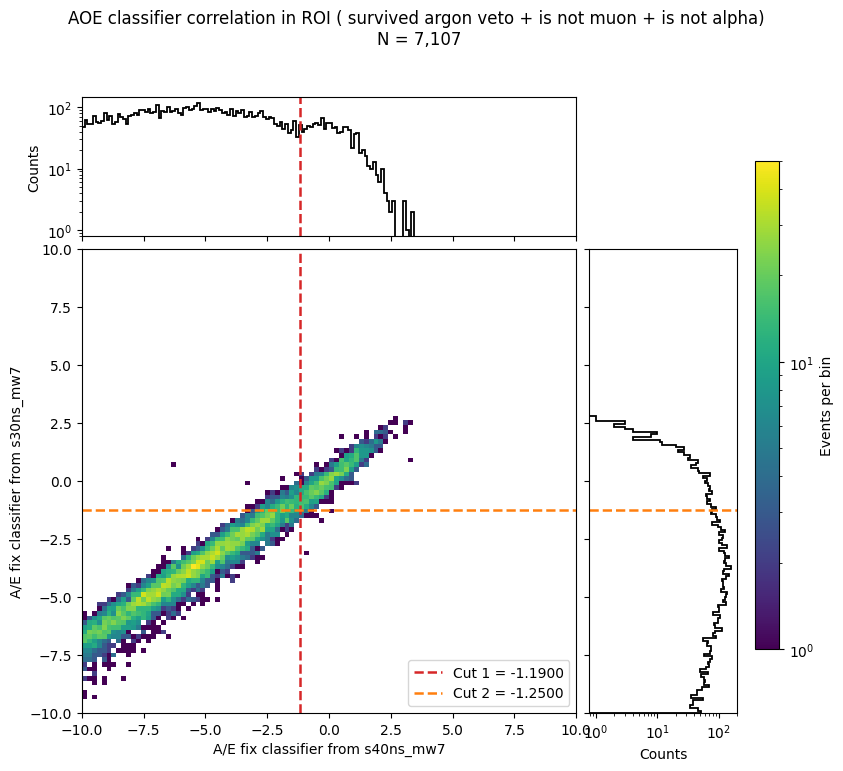

In [159]:
# zoomed in plot
range = [-10,10]
x_range = range
y_range = range
fig = plt.figure(figsize=(9, 8))

gs = GridSpec(
    2,
    2,
    figure=fig,
    width_ratios=(4, 1.2),
    height_ratios=(1.2, 4),
    hspace=0.04,
    wspace=0.04,
)

ax_top = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# ------------------------------------------------------------
# Central 2D correlation histogram
# ------------------------------------------------------------
hist = ax_main.hist2d(
    x,
    y,
    bins=(100, 100),
    range=(x_range, y_range),
    norm=LogNorm(),
    cmap="viridis",
)
n_events_in_plot = int(hist[0].sum())
# Numerical cut thresholds
ax_main.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_main.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_main.set_xlabel("A/E fix classifier from "+run_1)
ax_main.set_ylabel("A/E fix classifier from "+run_2)

# ------------------------------------------------------------
# Top marginal distribution: AOE_1
# ------------------------------------------------------------
ax_top.hist(
    x,
    bins=180,
    range=x_range,
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_top.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_top.set_ylabel("Counts")
ax_top.set_yscale("log")
ax_top.tick_params(axis="x", labelbottom=False)

# ------------------------------------------------------------
# Right marginal distribution: AOE_2
# ------------------------------------------------------------
ax_right.hist(
    y,
    bins=180,
    range=y_range,
    orientation="horizontal",
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_right.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_right.set_xlabel("Counts")
ax_right.set_xscale("log")
ax_right.tick_params(axis="y", labelleft=False)

# ------------------------------------------------------------
# Legend and colorbar
# ------------------------------------------------------------
legend_handles = [
    Line2D(
        [0], [0],
        color="tab:red",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 1 = {cut_value_1:.4f}",
    ),
    Line2D(
        [0], [0],
        color="tab:orange",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 2 = {cut_value_2:.4f}",
    ),
]

ax_main.legend(
    handles=legend_handles,
    loc="lower right",
)

cbar = fig.colorbar(
    hist[3],
    ax=[ax_main, ax_top, ax_right],
    fraction=0.035,
    pad=0.025,
)

cbar.set_label("Events per bin")

fig.suptitle(
    f"AOE classifier correlation in ROI ( survived argon veto + is not muon + is not alpha) \n"
    f"N = {n_events_in_plot:,}",
    y=0.99,
)

plt.show()

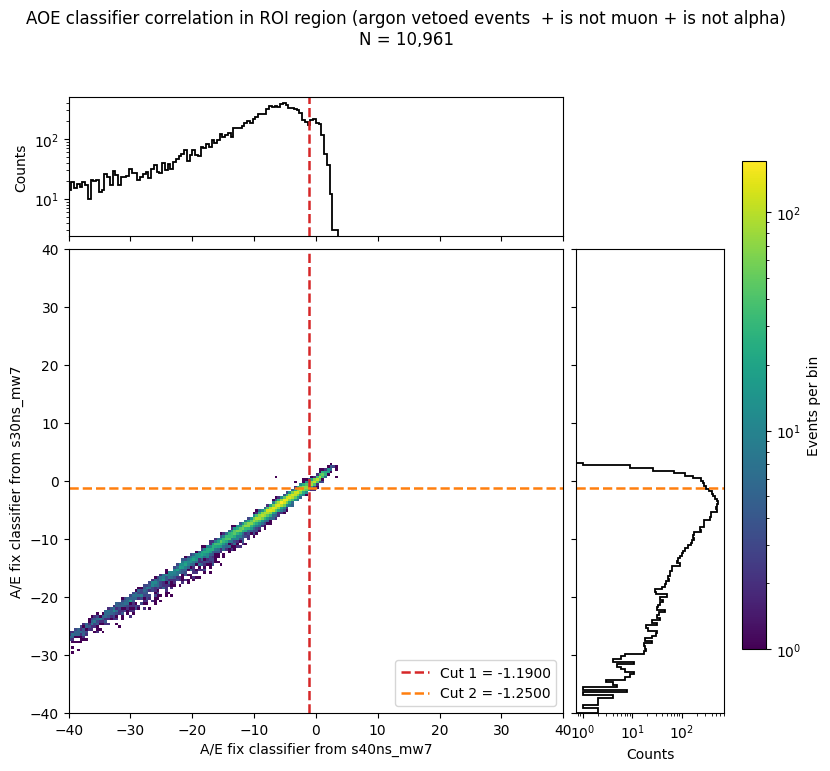

In [160]:
# full range plot
range = [-40,40]
x_range = range
y_range = range

fig = plt.figure(figsize=(9, 8))

gs = GridSpec(
    2,
    2,
    figure=fig,
    width_ratios=(4, 1.2),
    height_ratios=(1.2, 4),
    hspace=0.04,
    wspace=0.04,
)

ax_top = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# ------------------------------------------------------------
# Central 2D correlation histogram
# ------------------------------------------------------------
hist = ax_main.hist2d(
    x,
    y,
    bins=(180, 180),
    range=(x_range, y_range),
    norm=LogNorm(),
    cmap="viridis",
)
n_events_in_plot = int(hist[0].sum())
# Numerical cut thresholds
ax_main.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_main.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_main.set_xlabel("A/E fix classifier from "+run_1)
ax_main.set_ylabel("A/E fix classifier from "+run_2)

# ------------------------------------------------------------
# Top marginal distribution: AOE_1
# ------------------------------------------------------------
ax_top.hist(
    x,
    bins=180,
    range=x_range,
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_top.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_top.set_ylabel("Counts")
ax_top.set_yscale("log")
ax_top.tick_params(axis="x", labelbottom=False)

# ------------------------------------------------------------
# Right marginal distribution: AOE_2
# ------------------------------------------------------------
ax_right.hist(
    y,
    bins=180,
    range=y_range,
    orientation="horizontal",
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_right.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_right.set_xlabel("Counts")
ax_right.set_xscale("log")
ax_right.tick_params(axis="y", labelleft=False)

# ------------------------------------------------------------
# Legend and colorbar
# ------------------------------------------------------------
legend_handles = [
    Line2D(
        [0], [0],
        color="tab:red",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 1 = {cut_value_1:.4f}",
    ),
    Line2D(
        [0], [0],
        color="tab:orange",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 2 = {cut_value_2:.4f}",
    ),
]

ax_main.legend(
    handles=legend_handles,
    loc="lower right",
)

cbar = fig.colorbar(
    hist[3],
    ax=[ax_main, ax_top, ax_right],
    fraction=0.035,
    pad=0.025,
)

cbar.set_label("Events per bin")

fig.suptitle(
    f"AOE classifier correlation in ROI region (argon vetoed events  + is not muon + is not alpha)\n"
    f"N = {n_events_in_plot:,}",
    y=0.99,
)

plt.show()

## DEP

### event tier vetos

In [161]:
dfs_evt["r057"], lts_evt["r057"] = dataloader.load_lh5_run(
    ["ch002/evt"],
    "/mnt/atlas01/users/vogl/scarf/sp01/metadata/map.yaml",
    data_cleaning_path,
    "evt",
    "sp01",
    "p05",
    "r057",
    "cal",
    ["ch002"],
)

In [162]:
dfs_cal_evt = dfs_evt['r057']['ch002']

In [163]:
argon_veto = np.asarray(dfs_cal_evt.is_lar_vetoed)
muon_veto = np.asarray(dfs_cal_evt.is_muon)
alpha_veto = np.asarray(dfs_cal_evt.A_max_o_E_High_Side_Cut & (dfs_cal_evt.Iasy<0))

### readfiles

In [164]:
dfs_1["r057"], lts_1["r057"] = dataloader.load_lh5_run(
    ["ch002/hit"],
    map_path(run_1),
    data_cleaning_path,
    "hit",
    "sp01",
    "p05",
    "r057",
    "cal",
    ["ch002"],
)

In [165]:
dfs_2["r057"], lts_2["r057"] = dataloader.load_lh5_run(
    ["ch002/hit"],
    map_path(run_2),
    data_cleaning_path,
    "hit",
    "sp01",
    "p05",
    "r057",
    "cal",
    ["ch002"],
)

In [166]:
dfs_cal_1 = dfs_1['r057']['ch002']
dfs_cal_2 = dfs_2['r057']['ch002']

In [167]:
E_1=np.asarray(dfs_cal_1.trapEmax_fix_cal)
A_max_mw_o_E_Classifier_1 = np.asarray(dfs_cal_1.A_max_mw_o_E_fix_Classifier)
is_valid_waveform_1 = np.asarray(dfs_cal_1.is_valid_waveform)
E_2=np.asarray(dfs_cal_2.trapEmax_fix_cal)
A_max_mw_o_E_Classifier_2 = np.asarray(dfs_cal_2.A_max_mw_o_E_fix_Classifier)
is_valid_waveform_2 = np.asarray(dfs_cal_2.is_valid_waveform)

In [168]:
DEP_mask = (E_1 > 1585) & (E_1 < 1600)
# Check that all arrays correspond to the same events
assert (
    A_max_mw_o_E_Classifier_1.shape
    == A_max_mw_o_E_Classifier_2.shape
    == DEP_mask.shape
    == argon_veto.shape
    # == low_cut_1.shape
    # == low_cut_2.shape
), (
    f"Shape mismatch: "
    f"A_max_mw_o_E_Classifier_1={A_max_mw_o_E_Classifier_1.shape}, "
    f"A_max_mw_o_E_Classifier_2={A_max_mw_o_E_Classifier_2.shape}, "
    f"ROI_mask={ROI_mask.shape}, "
    # f"low_cut_1={low_cut_1.shape}, "
    # f"low_cut_2={low_cut_2.shape}"
)

# ROI selection plus finite classifier values
selection = (
    DEP_mask
    & np.isfinite(A_max_mw_o_E_Classifier_1)
    & np.isfinite(A_max_mw_o_E_Classifier_2)
    & ~argon_veto
    & ~muon_veto
    & alpha_veto
)

# Selected classifier values
x = A_max_mw_o_E_Classifier_1[selection]
y = A_max_mw_o_E_Classifier_2[selection]

# # Selected Boolean cut decisions
# pass_1 = low_cut_1[selection]
# pass_2 = low_cut_2[selection]

print(f"Selected ROI events: {len(x):,}")

Selected ROI events: 432


### plots

In [169]:
# zoomed in plot
range = [-10,10]
x_range = range
y_range = range
fig = plt.figure(figsize=(9, 8))

gs = GridSpec(
    2,
    2,
    figure=fig,
    width_ratios=(4, 1.2),
    height_ratios=(1.2, 4),
    hspace=0.04,
    wspace=0.04,
)

ax_top = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# ------------------------------------------------------------
# Central 2D correlation histogram
# ------------------------------------------------------------
hist = ax_main.hist2d(
    x,
    y,
    bins=(180, 180),
    range=(x_range, y_range),
    norm=LogNorm(),
    cmap="viridis",
)
n_events_in_plot = int(hist[0].sum())
# Numerical cut thresholds
ax_main.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_main.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_main.set_xlabel("A/E fix classifier from "+run_1)
ax_main.set_ylabel("A/E fix classifier from "+run_2)

# ------------------------------------------------------------
# Top marginal distribution: AOE_1
# ------------------------------------------------------------
ax_top.hist(
    x, 

ax_top.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_top.set_ylabel("Counts")
ax_top.set_yscale("log")
ax_top.tick_params(axis="x", labelbottom=False)

# ------------------------------------------------------------
# Right marginal distribution: AOE_2
# ------------------------------------------------------------
ax_right.hist(
    y,
    bins=180,
    range=y_range,
    orientation="horizontal",
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_right.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_right.set_xlabel("Counts")
ax_right.set_xscale("log")
ax_right.tick_params(axis="y", labelleft=False)

# ------------------------------------------------------------
# Legend and colorbar
# ------------------------------------------------------------
legend_handles = [
    Line2D(
        [0], [0],
        color="tab:red",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 1 = {cut_value_1:.4f}",
    ),
    Line2D(
        [0], [0],
        color="tab:orange",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 2 = {cut_value_2:.4f}",
    ),
]

ax_main.legend(
    handles=legend_handles,
    loc="lower right",
)

cbar = fig.colorbar(
    hist[3],
    ax=[ax_main, ax_top, ax_right],
    fraction=0.035,
    pad=0.025,
)

cbar.set_label("Events per bin")

fig.suptitle(
    f"AOE classifier correlation in DEP\n"
    f"N = {n_events_in_plot:,}",
    y=0.99,
)

plt.show()

SyntaxError: '(' was never closed (3598546585.py, line 54)

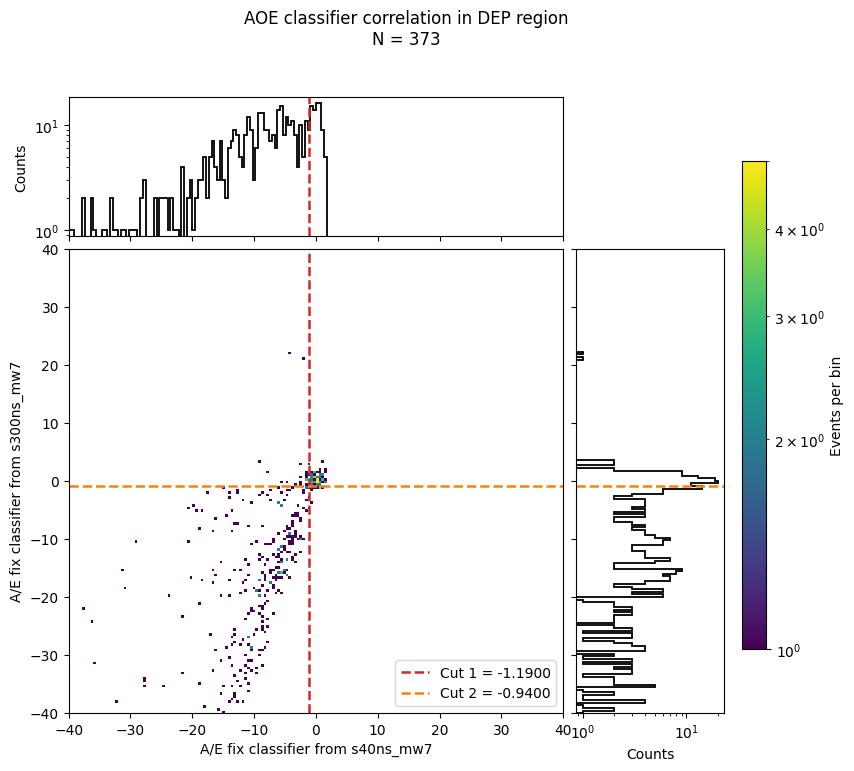

In [ ]:
# full range plot
range = [-40,40]
x_range = range
y_range = range

fig = plt.figure(figsize=(9, 8))

gs = GridSpec(
    2,
    2,
    figure=fig,
    width_ratios=(4, 1.2),
    height_ratios=(1.2, 4),
    hspace=0.04,
    wspace=0.04,
)

ax_top = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# ------------------------------------------------------------
# Central 2D correlation histogram
# ------------------------------------------------------------
hist = ax_main.hist2d(
    x,
    y,
    bins=(180, 180),
    range=(x_range, y_range),
    norm=LogNorm(),
    cmap="viridis",
)
n_events_in_plot = int(hist[0].sum())
# Numerical cut thresholds
ax_main.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_main.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_main.set_xlabel("A/E fix classifier from "+run_1)
ax_main.set_ylabel("A/E fix classifier from "+run_2)

# ------------------------------------------------------------
# Top marginal distribution: AOE_1
# ------------------------------------------------------------
ax_top.hist(
    x,
    bins=180,
    range=x_range,
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_top.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_top.set_ylabel("Counts")
ax_top.set_yscale("log")
ax_top.tick_params(axis="x", labelbottom=False)

# ------------------------------------------------------------
# Right marginal distribution: AOE_2
# ------------------------------------------------------------
ax_right.hist(
    y,
    bins=180,
    range=y_range,
    orientation="horizontal",
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_right.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_right.set_xlabel("Counts")
ax_right.set_xscale("log")
ax_right.tick_params(axis="y", labelleft=False)

# ------------------------------------------------------------
# Legend and colorbar
# ------------------------------------------------------------
legend_handles = [
    Line2D(
        [0], [0],
        color="tab:red",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 1 = {cut_value_1:.4f}",
    ),
    Line2D(
        [0], [0],
        color="tab:orange",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 2 = {cut_value_2:.4f}",
    ),
]

ax_main.legend(
    handles=legend_handles,
    loc="lower right",
)

cbar = fig.colorbar(
    hist[3],
    ax=[ax_main, ax_top, ax_right],
    fraction=0.035,
    pad=0.025,
)

cbar.set_label("Events per bin")

fig.suptitle(
    f"AOE classifier correlation in DEP region\n"
    f"N = {n_events_in_plot:,}",
    y=0.99,
)

plt.show()

## FEP

In [ ]:
FEP_mask = (E_1 > 2605) & (E_1 < 2625)
# Check that all arrays correspond to the same events
assert (
    A_max_mw_o_E_Classifier_1.shape
    == A_max_mw_o_E_Classifier_2.shape
    == FEP_mask.shape
), (
    f"Shape mismatch: "
    f"A_max_mw_o_E_Classifier_1={A_max_mw_o_E_Classifier_1.shape}, "
    f"A_max_mw_o_E_Classifier_2={A_max_mw_o_E_Classifier_2.shape}, "
    f"FEP_mask={FEP_mask.shape}, "
)

# FEP selection plus finite classifier values
selection = (
    FEP_mask
    & np.isfinite(A_max_mw_o_E_Classifier_1)
    & np.isfinite(A_max_mw_o_E_Classifier_2)
    & argon_veto
    & ~muon_veto
    & alpha_veto
)

# Selected classifier values
x = A_max_mw_o_E_Classifier_1[selection]
y = A_max_mw_o_E_Classifier_2[selection]



### plots

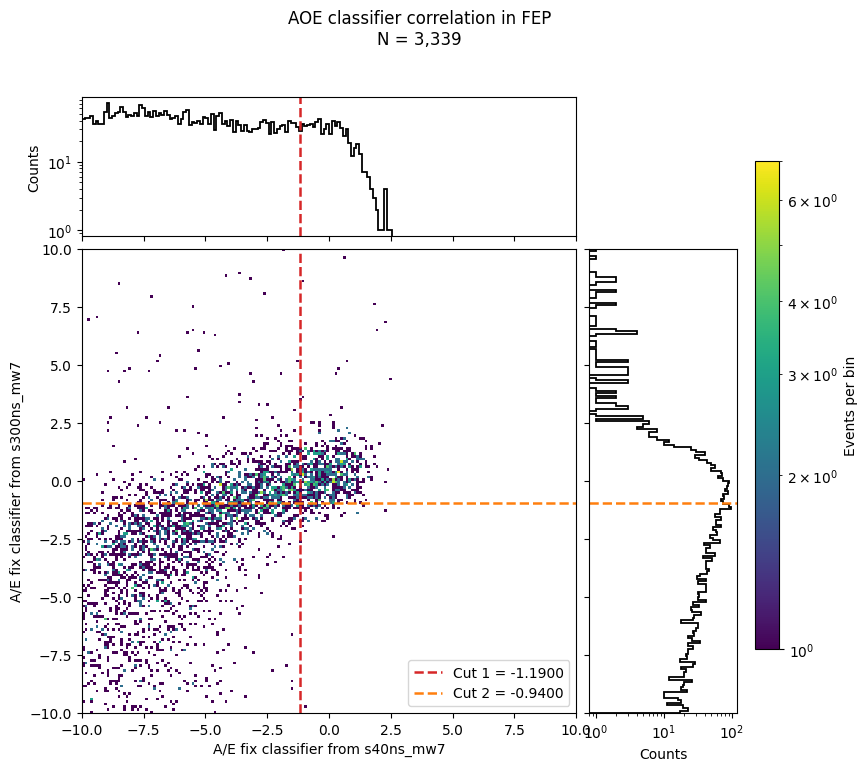

In [ ]:
# zoomed in plot
# The underlying Boolean statistics still use all selected DEP events.
# x_range = tuple(np.percentile(x, [0.2, 99.8]))
# y_range = tuple(np.percentile(y, [0.2, 99.8]))
range = [-10,10]
x_range = range
y_range = range
fig = plt.figure(figsize=(9, 8))

gs = GridSpec(
    2,
    2,
    figure=fig,
    width_ratios=(4, 1.2),
    height_ratios=(1.2, 4),
    hspace=0.04,
    wspace=0.04,
)

ax_top = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# ------------------------------------------------------------
# Central 2D correlation histogram
# ------------------------------------------------------------
hist = ax_main.hist2d(
    x,
    y,
    bins=(180, 180),
    range=(x_range, y_range),
    norm=LogNorm(),
    cmap="viridis",
)
n_events_in_plot = int(hist[0].sum())
# Numerical cut thresholds
ax_main.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_main.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_main.set_xlabel("A/E fix classifier from "+run_1)
ax_main.set_ylabel("A/E fix classifier from "+run_2)

# ------------------------------------------------------------
# Top marginal distribution: AOE_1
# ------------------------------------------------------------
ax_top.hist(
    x,
    bins=180,
    range=x_range,
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_top.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_top.set_ylabel("Counts")
ax_top.set_yscale("log")
ax_top.tick_params(axis="x", labelbottom=False)

# ------------------------------------------------------------
# Right marginal distribution: AOE_2
# ------------------------------------------------------------
ax_right.hist(
    y,
    bins=180,
    range=y_range,
    orientation="horizontal",
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_right.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_right.set_xlabel("Counts")
ax_right.set_xscale("log")
ax_right.tick_params(axis="y", labelleft=False)

# ------------------------------------------------------------
# Legend and colorbar
# ------------------------------------------------------------
legend_handles = [
    Line2D(
        [0], [0],
        color="tab:red",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 1 = {cut_value_1:.4f}",
    ),
    Line2D(
        [0], [0],
        color="tab:orange",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 2 = {cut_value_2:.4f}",
    ),
]

ax_main.legend(
    handles=legend_handles,
    loc="lower right",
)

cbar = fig.colorbar(
    hist[3],
    ax=[ax_main, ax_top, ax_right],
    fraction=0.035,
    pad=0.025,
)

cbar.set_label("Events per bin")

fig.suptitle(
    f"AOE classifier correlation in FEP\n"
    f"N = {n_events_in_plot:,}",
    y=0.99,
)

plt.show()

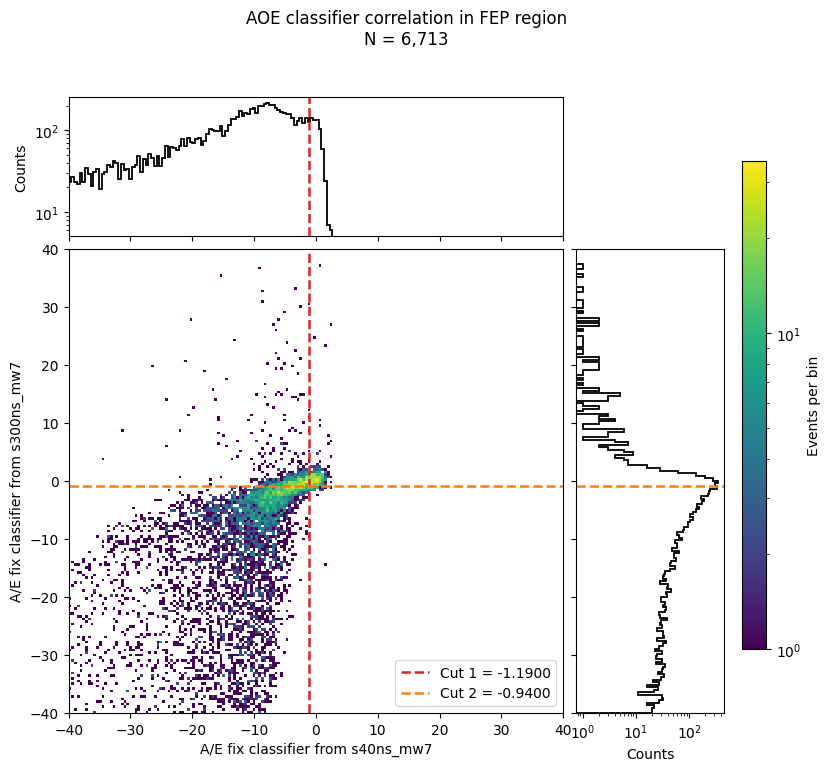

In [ ]:
# full range plot
# The underlying Boolean statistics still use all selected DEP events.
# x_range = tuple(np.percentile(x, [0.2, 99.8]))
range = [-40,40]
x_range = range
y_range = range

fig = plt.figure(figsize=(9, 8))

gs = GridSpec(
    2,
    2,
    figure=fig,
    width_ratios=(4, 1.2),
    height_ratios=(1.2, 4),
    hspace=0.04,
    wspace=0.04,
)

ax_top = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# ------------------------------------------------------------
# Central 2D correlation histogram
# ------------------------------------------------------------
hist = ax_main.hist2d(
    x,
    y,
    bins=(180, 180),
    range=(x_range, y_range),
    norm=LogNorm(),
    cmap="viridis",
)
n_events_in_plot = int(hist[0].sum())
# Numerical cut thresholds
ax_main.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_main.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_main.set_xlabel("A/E fix classifier from "+run_1)
ax_main.set_ylabel("A/E fix classifier from "+run_2)

# ------------------------------------------------------------
# Top marginal distribution: AOE_1
# ------------------------------------------------------------
ax_top.hist(
    x,
    bins=180,
    range=x_range,
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_top.axvline(
    cut_value_1,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

ax_top.set_ylabel("Counts")
ax_top.set_yscale("log")
ax_top.tick_params(axis="x", labelbottom=False)

# ------------------------------------------------------------
# Right marginal distribution: AOE_2
# ------------------------------------------------------------
ax_right.hist(
    y,
    bins=180,
    range=y_range,
    orientation="horizontal",
    histtype="step",
    color="black",
    linewidth=1.3,
)

ax_right.axhline(
    cut_value_2,
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
)

ax_right.set_xlabel("Counts")
ax_right.set_xscale("log")
ax_right.tick_params(axis="y", labelleft=False)

# ------------------------------------------------------------
# Legend and colorbar
# ------------------------------------------------------------
legend_handles = [
    Line2D(
        [0], [0],
        color="tab:red",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 1 = {cut_value_1:.4f}",
    ),
    Line2D(
        [0], [0],
        color="tab:orange",
        linestyle="--",
        linewidth=1.8,
        label=f"Cut 2 = {cut_value_2:.4f}",
    ),
]

ax_main.legend(
    handles=legend_handles,
    loc="lower right",
)

cbar = fig.colorbar(
    hist[3],
    ax=[ax_main, ax_top, ax_right],
    fraction=0.035,
    pad=0.025,
)

cbar.set_label("Events per bin")

fig.suptitle(
    f"AOE classifier correlation in FEP region\n"
    f"N = {n_events_in_plot:,}",
    y=0.99,
)

plt.show()